In [74]:
import pandas as pd

In [75]:
# format of data:
# Date // Confirmed_cases // Suspected_cases // Suspected_deaths // Confirmed_deaths // Contacts_listed 


In [76]:
df=pd.read_excel('/home/moez/Desktop/data_thiery/data ebola/new cases data.xlsx')
df['Date']=pd.to_datetime(df['Date'], dayfirst=True)
df['Day']=df['Date'].dt.day
df['Date'] = df['Date'].dt.strftime('%d/%m/%Y')
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
df.head()

,Date,Confirmed_cases,Suspected_cases,Suspected_deaths,Confirmed_deaths,Contacts_listed,Day
0,2026-05-16,NaN,NaN,105,NaN,NaN,16
1,2026-05-17,NaN,NaN,105,NaN,NaN,17
2,2026-05-18,8.0,393.0,105,3.0,668.0,18
3,2026-05-19,35.0,516.0,132,4.0,668.0,19
4,2026-05-20,50.0,601.0,150,5.0,974.0,20


In [77]:
# we chose to start from 18 may
df=df[df['Day']>=18].copy()
df

,Date,Confirmed_cases,Suspected_cases,Suspected_deaths,Confirmed_deaths,Contacts_listed,Day
2,2026-05-18,8.0,393.0,105,3.0,668.0,18
3,2026-05-19,35.0,516.0,132,4.0,668.0,19
4,2026-05-20,50.0,601.0,150,5.0,974.0,20
5,2026-05-21,65.0,686.0,168,7.0,1231.0,21
6,2026-05-22,80.0,771.0,186,9.0,1488.0,22
7,2026-05-23,96.0,866.0,202,10.0,1745.0,23
8,2026-05-24,108.0,903.0,202,11.0,1817.0,24
9,2026-05-25,112.0,906.0,223,11.0,2231.0,25
10,2026-05-26,112.0,998.0,238,13.0,2231.0,26


In [78]:
# Data should be interpolated in advance or filled manually by values (no nan values) else do this
"""df.columns = df.columns.str.strip()
full_range=pd.DataFrame({'Day':range(df['Day'].min(),df['Day'].max()+1)})
df=pd.merge(full_range,df,on='Day',how='left')
df_interp=df[['CasSuspect','DecesSuspect','CasConfirmes','Contacts']]
df_interp=df_interp.interpolate(method='linear')
df_interp['Day']=df['Day']
df=df_interp.copy()
df.head() """

"df.columns = df.columns.str.strip()\nfull_range=pd.DataFrame({'Day':range(df['Day'].min(),df['Day'].max()+1)})\ndf=pd.merge(full_range,df,on='Day',how='left')\ndf_interp=df[['CasSuspect','DecesSuspect','CasConfirmes','Contacts']]\ndf_interp=df_interp.interpolate(method='linear')\ndf_interp['Day']=df['Day']\ndf=df_interp.copy()\ndf.head() "

In [79]:
# adding a proportion p from suspected

# suspected cases: 
p1=0
df['Confirmed_cases']= df['Confirmed_cases'] + p1 * df['Suspected_cases']

# suspected deaths: 
p2=0
df['Confirmed_deaths']= df['Confirmed_deaths'] + p2 * df['Suspected_deaths']

In [80]:
# calculating incidence
df['new_confirmed_cases'] = df['Confirmed_cases'].diff().fillna(df['Confirmed_cases']).clip(lower=0).astype(int)
df['new_confirmed_deaths'] = df['Confirmed_deaths'].diff().fillna(df['Confirmed_deaths']).clip(lower=0).astype(int)

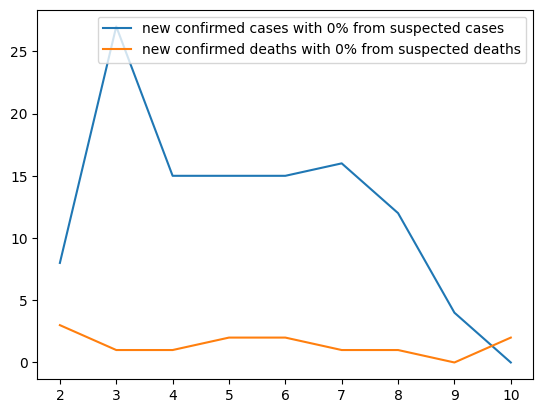

In [81]:
# smoothing
import matplotlib.pyplot  as plt
plt.plot(df['new_confirmed_cases'], label=f'new confirmed cases with {p1*100}% from suspected cases')
plt.plot(df['new_confirmed_deaths'], label=f'new confirmed deaths with {p2*100}% from suspected deaths')
plt.legend()

In [82]:
# rolling mean (2 days window)
"""df['smoothed_confirmed_cases'] = df['new_confirmed_cases'].rolling(
    window=2,
    center=True,
    min_periods=1
).mean()
df['smoothed_confirmed_deaths'] = df['new_confirmed_deaths'].rolling(
    window=2,
    center=True,
    min_periods=1
).mean()"""


"df['smoothed_confirmed_cases'] = df['new_confirmed_cases'].rolling(\n    window=2,\n    center=True,\n    min_periods=1\n).mean()\ndf['smoothed_confirmed_deaths'] = df['new_confirmed_deaths'].rolling(\n    window=2,\n    center=True,\n    min_periods=1\n).mean()"

In [83]:
"""BLUE  = '#1F6FBF'
RED   = '#C0392B'
plt.plot(df['new_confirmed_cases'],'--',color=BLUE, label='new confirmed cases')
plt.plot(df['smoothed_confirmed_cases'],'-',color=BLUE, label='smoothed confirmed deaths')
plt.plot(df['new_confirmed_deaths'],'--',color=RED, label='new confirmed cases')
plt.plot(df['smoothed_confirmed_deaths'],'-',color=RED, label='smoothed confirmed deaths')
plt.title('Rolling mean smoothing')
plt.xlabel('Days')
plt.ylabel('Count')

plt.legend()"""

"BLUE  = '#1F6FBF'\nRED   = '#C0392B'\nplt.plot(df['new_confirmed_cases'],'--',color=BLUE, label='new confirmed cases')\nplt.plot(df['smoothed_confirmed_cases'],'-',color=BLUE, label='smoothed confirmed deaths')\nplt.plot(df['new_confirmed_deaths'],'--',color=RED, label='new confirmed cases')\nplt.plot(df['smoothed_confirmed_deaths'],'-',color=RED, label='smoothed confirmed deaths')\nplt.title('Rolling mean smoothing')\nplt.xlabel('Days')\nplt.ylabel('Count')\n\nplt.legend()"

In [84]:
# Savitzky-Golay (polynomial)
from scipy.signal import savgol_filter
df['smoothed_confirmed_cases']=savgol_filter(
    df['new_confirmed_cases'],
    window_length=5,   # odd number
    polyorder=2
)
df['smoothed_confirmed_deaths'] = savgol_filter(
    df['new_confirmed_deaths'],
    window_length=5,   # odd number
    polyorder=2
)

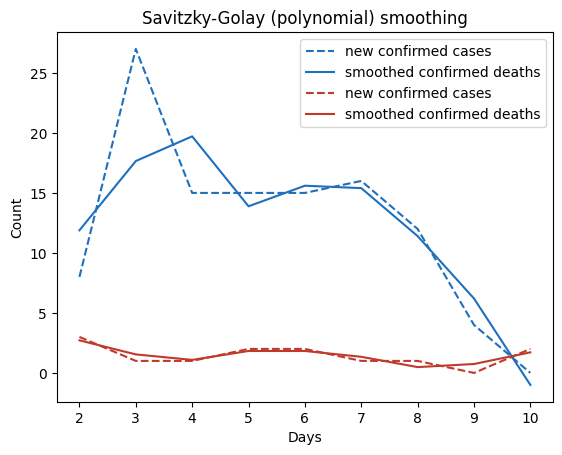

In [85]:
plt.plot(df['new_confirmed_cases'],'--',color=BLUE, label='new confirmed cases')
plt.plot(df['smoothed_confirmed_cases'],'-',color=BLUE, label='smoothed confirmed deaths')
plt.plot(df['new_confirmed_deaths'],'--',color=RED, label='new confirmed cases')
plt.plot(df['smoothed_confirmed_deaths'],'-',color=RED, label='smoothed confirmed deaths')
plt.title('Savitzky-Golay (polynomial) smoothing')
plt.xlabel('Days')
plt.ylabel('Count')

plt.legend()

In [86]:
# Locally weighted polynomial regression
"""from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np

x = np.arange(len(df['new_confirmed_cases']))

smooth1 = lowess(
    df['new_confirmed_cases'],
    x,
    frac=0.2
)
smooth2 = lowess(
    df['new_confirmed_deaths'],
    x,
    frac=0.2
)
df['smoothed_confirmed_deaths']=smooth2[:,1]
df['smoothed_confirmed_cases'] = smooth1[:,1]"""

"from statsmodels.nonparametric.smoothers_lowess import lowess\nimport numpy as np\n\nx = np.arange(len(df['new_confirmed_cases']))\n\nsmooth1 = lowess(\n    df['new_confirmed_cases'],\n    x,\n    frac=0.2\n)\nsmooth2 = lowess(\n    df['new_confirmed_deaths'],\n    x,\n    frac=0.2\n)\ndf['smoothed_confirmed_deaths']=smooth2[:,1]\ndf['smoothed_confirmed_cases'] = smooth1[:,1]"

In [87]:
"""plt.plot(df['new_confirmed_cases'],'--',color=BLUE, label='new confirmed cases')
plt.plot(df['smoothed_confirmed_cases'],'-',color=BLUE, label='smoothed confirmed deaths')
plt.plot(df['new_confirmed_deaths'],'--',color=RED, label='new confirmed cases')
plt.plot(df['smoothed_confirmed_deaths'],'-',color=RED, label='smoothed confirmed deaths')
plt.title('Locally weighted polynomial regression smoothing')
plt.xlabel('Days')
plt.ylabel('Count')

plt.legend()"""

"plt.plot(df['new_confirmed_cases'],'--',color=BLUE, label='new confirmed cases')\nplt.plot(df['smoothed_confirmed_cases'],'-',color=BLUE, label='smoothed confirmed deaths')\nplt.plot(df['new_confirmed_deaths'],'--',color=RED, label='new confirmed cases')\nplt.plot(df['smoothed_confirmed_deaths'],'-',color=RED, label='smoothed confirmed deaths')\nplt.title('Locally weighted polynomial regression smoothing')\nplt.xlabel('Days')\nplt.ylabel('Count')\n\nplt.legend()"

In [88]:
# Smoothing Splines
"""from scipy.interpolate import UnivariateSpline

spl1 = UnivariateSpline(
    x,
    df['new_confirmed_cases'],
    s=10
)

spl2 = UnivariateSpline(
    x,
    df['new_confirmed_deaths'],
    s=10
)

df['smoothed_confirmed_cases'] = spl1(x)
df['smoothed_confirmed_deaths'] = spl2(x)"""

"from scipy.interpolate import UnivariateSpline\n\nspl1 = UnivariateSpline(\n    x,\n    df['new_confirmed_cases'],\n    s=10\n)\n\nspl2 = UnivariateSpline(\n    x,\n    df['new_confirmed_deaths'],\n    s=10\n)\n\ndf['smoothed_confirmed_cases'] = spl1(x)\ndf['smoothed_confirmed_deaths'] = spl2(x)"

In [89]:
"""plt.plot(df['new_confirmed_cases'],'--',color=BLUE, label='new confirmed cases')
plt.plot(df['smoothed_confirmed_cases'],'-',color=BLUE, label='smoothed confirmed deaths')
plt.plot(df['new_confirmed_deaths'],'--',color=RED, label='new confirmed cases')
plt.plot(df['smoothed_confirmed_deaths'],'-',color=RED, label='smoothed confirmed deaths')
plt.title('Smoothing Splines')
plt.xlabel('Days')
plt.ylabel('Count')

plt.legend()"""

"plt.plot(df['new_confirmed_cases'],'--',color=BLUE, label='new confirmed cases')\nplt.plot(df['smoothed_confirmed_cases'],'-',color=BLUE, label='smoothed confirmed deaths')\nplt.plot(df['new_confirmed_deaths'],'--',color=RED, label='new confirmed cases')\nplt.plot(df['smoothed_confirmed_deaths'],'-',color=RED, label='smoothed confirmed deaths')\nplt.title('Smoothing Splines')\nplt.xlabel('Days')\nplt.ylabel('Count')\n\nplt.legend()"

In [90]:
# Gaussian Filter
"""from scipy.ndimage import gaussian_filter1d

df['smoothed_confirmed_cases'] = gaussian_filter1d(
    df['new_confirmed_cases'],
    sigma=1
)
df['smoothed_confirmed_deaths'] = gaussian_filter1d(
    df['new_confirmed_deaths'],
    sigma=1
)"""

"from scipy.ndimage import gaussian_filter1d\n\ndf['smoothed_confirmed_cases'] = gaussian_filter1d(\n    df['new_confirmed_cases'],\n    sigma=1\n)\ndf['smoothed_confirmed_deaths'] = gaussian_filter1d(\n    df['new_confirmed_deaths'],\n    sigma=1\n)"

In [91]:
"""plt.plot(df['new_confirmed_cases'],'--',color=BLUE, label='new confirmed cases')
plt.plot(df['smoothed_confirmed_cases'],'-',color=BLUE, label='smoothed confirmed deaths')
plt.plot(df['new_confirmed_deaths'],'--',color=RED, label='new confirmed cases')
plt.plot(df['smoothed_confirmed_deaths'],'-',color=RED, label='smoothed confirmed deaths')
plt.title('Gaussian Filter')
plt.xlabel('Days')
plt.ylabel('Count')

plt.legend()"""

"plt.plot(df['new_confirmed_cases'],'--',color=BLUE, label='new confirmed cases')\nplt.plot(df['smoothed_confirmed_cases'],'-',color=BLUE, label='smoothed confirmed deaths')\nplt.plot(df['new_confirmed_deaths'],'--',color=RED, label='new confirmed cases')\nplt.plot(df['smoothed_confirmed_deaths'],'-',color=RED, label='smoothed confirmed deaths')\nplt.title('Gaussian Filter')\nplt.xlabel('Days')\nplt.ylabel('Count')\n\nplt.legend()"

In [92]:
# KalmanFilter
"""from pykalman import KalmanFilter

kf1 = KalmanFilter(initial_state_mean=df['new_confirmed_cases'][2])
kf2 = KalmanFilter(initial_state_mean=df['new_confirmed_deaths'][2])

smooth1, _ = kf1.smooth(df['new_confirmed_cases'])
smooth2, _ = kf2.smooth(df['new_confirmed_deaths'])
df['smoothed_confirmed_cases'] = smooth1.flatten()
df['smoothed_confirmed_deaths'] = smooth2.flatten()"""

"from pykalman import KalmanFilter\n\nkf1 = KalmanFilter(initial_state_mean=df['new_confirmed_cases'][2])\nkf2 = KalmanFilter(initial_state_mean=df['new_confirmed_deaths'][2])\n\nsmooth1, _ = kf1.smooth(df['new_confirmed_cases'])\nsmooth2, _ = kf2.smooth(df['new_confirmed_deaths'])\ndf['smoothed_confirmed_cases'] = smooth1.flatten()\ndf['smoothed_confirmed_deaths'] = smooth2.flatten()"

In [93]:
"""plt.plot(df['new_confirmed_cases'],'--',color=BLUE, label='new confirmed cases')
plt.plot(df['smoothed_confirmed_cases'],'-',color=BLUE, label='smoothed confirmed deaths')
plt.plot(df['new_confirmed_deaths'],'--',color=RED, label='new confirmed cases')
plt.plot(df['smoothed_confirmed_deaths'],'-',color=RED, label='smoothed confirmed deaths')
plt.title('Kalman Filter')
plt.xlabel('Days')
plt.ylabel('Count')

plt.legend()"""

"plt.plot(df['new_confirmed_cases'],'--',color=BLUE, label='new confirmed cases')\nplt.plot(df['smoothed_confirmed_cases'],'-',color=BLUE, label='smoothed confirmed deaths')\nplt.plot(df['new_confirmed_deaths'],'--',color=RED, label='new confirmed cases')\nplt.plot(df['smoothed_confirmed_deaths'],'-',color=RED, label='smoothed confirmed deaths')\nplt.title('Kalman Filter')\nplt.xlabel('Days')\nplt.ylabel('Count')\n\nplt.legend()"

In [94]:
# setting negative values to zero:
df['smoothed_confirmed_cases'] = df['smoothed_confirmed_cases'].clip(lower=0)
df['smoothed_confirmed_deaths']=df['smoothed_confirmed_deaths'].clip(lower=0)

In [95]:
# replace with your location
# we choose polynomial smoothing
df.to_csv('smoothed incidence cases data.csv')

In [98]:
df

,Date,Confirmed_cases,Suspected_cases,Suspected_deaths,Confirmed_deaths,Contacts_listed,Day,new_confirmed_cases,new_confirmed_deaths,smoothed_confirmed_cases,smoothed_confirmed_deaths
2,2026-05-18,8.0,393.0,105,3.0,668.0,18,8,3,11.885714,2.714286
3,2026-05-19,35.0,516.0,132,4.0,668.0,19,27,1,17.657143,1.542857
4,2026-05-20,50.0,601.0,150,5.0,974.0,20,15,1,19.714286,1.085714
5,2026-05-21,65.0,686.0,168,7.0,1231.0,21,15,2,13.885714,1.828571
6,2026-05-22,80.0,771.0,186,9.0,1488.0,22,15,2,15.600000,1.828571
7,2026-05-23,96.0,866.0,202,10.0,1745.0,23,16,1,15.400000,1.342857
8,2026-05-24,108.0,903.0,202,11.0,1817.0,24,12,1,11.400000,0.485714
9,2026-05-25,112.0,906.0,223,11.0,2231.0,25,4,0,6.200000,0.742857
10,2026-05-26,112.0,998.0,238,13.0,2231.0,26,0,2,0.000000,1.714286
